# Ice-nucleating particle (INP) database (INPDB) post processing notebook

## Overview
This Jupyter notebook includes functions for INPDB I/O, post-processing (mapping functions e.g. season, lat band, hemisphere, online/offline instrument) and visualization (e.g., global INP map).

This work has received funding from the Swiss State Secretariat for Education, Research and Innovation (SERI) for the Horizon Europe programme under Grant Agreement No 101137680 via project CERTAINTY (Cloud-aERosol inTeractions & their impActs IN The earth sYstem).

In [1]:
__author__ = "Cuiqi Zhang"
__copyright__ = "CERTAINTY 2024-2027. All rights reserved."
__credits__ = ["Cuiqi Zhang"]
__license__ = "GPL-3.0, https://opensource.org/license/GPL-3.0"
__version__ = "1.0.1"
__maintainer__ = "Cuiqi Zhang"
__email__ = "cuiqi.zhang@env.ethz.ch"
__contactPerson__ = "Zamin A. Kanji"
__contactEmail__ = "zamin.kanji@env.ethz.ch"
__status__ = "Production"

# Initialization

In [2]:
import os
from datetime import datetime as dt
from datetime import timedelta
import glob, sys
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import re

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# I/O

In [3]:
def readINPDB(fn_INPDB):
    data_INPDB = pd.read_csv(fn_INPDB, sep=',', index_col=False, skiprows=0, dtype='str')
    data = data_INPDB.copy()
    for key in ['Day', 'Month', 'Year', 'T [K]', 'RHw [%]', 'RHi [%]', 'IN [L-1]', 'Lat', 'Lon', 'Alt [m]']:
        data[key] = pd.to_numeric(data[key], errors='coerce') # convert bad non numeric values to NaN
    return data
fn_INPDB = r"INPDB_sample_data.csv"
data = readINPDB(fn_INPDB)

In [12]:
def INPDB_output(data, fn_out):
    data.to_csv(fn_out, index=False)

outputDir = "Output"
try:
    os.makedirs(outputDir, exist_ok=True) ## Create the output directory if it doesn't exist
    print(f"Output directory '{outputDir}' is ready.")
except Exception as e:
    print(f"Error creating output directory: {e}")

fn_out = os.path.join(outputDir, "output.csv")
# INPDB_output(data, fn_out) ## Uncomment to save the dataset


Output directory 'Output' is ready.


# Post-processing

### Mapping

### Season

In [5]:
def mapping_Season(data, idx):
    ## add season based on Month
    season_mapping = {
    12: 'DJF', 1: 'DJF', 2: 'DJF',  ## N. H. Winter
    3: 'MAM', 4: 'MAM', 5: 'MAM',   ## N. H. Spring
    6: 'JJA', 7: 'JJA', 8: 'JJA',   ## N. H. Summer
    9: 'SON', 10: 'SON', 11: 'SON'  ## N. H. Autumn
}

    ## Apply the mapping to create a new 'Season' column
    data.loc[idx, 'Season'] = data['Month'].map(season_mapping)
    return data

data = mapping_Season(data, data.index)

### Lat bands

In [6]:
def mapping_LatBand(data, idx):
    """
    Add latitude band based on Lat
    """
    lat_band_mapping = {
        (-91, -66.56083): 'Antarctica',  ## Antarctica
        (-66.56083, -23.43607): "S. Mid-lat.", 
        (-23.43607, 23.43607): 'Tropics',  ## Tropics
        (23.43607, 66.56083): 'N. Mid-lat.',  ## N. Mid-lat.
        (66.56083, 91): 'Polar'  ## Polar
    }

    def get_lat_band(lat):
        for (low, high), band in lat_band_mapping.items():
            if low <= lat < high:
                return band
        return 'Unknown'

    data.loc[idx, 'LatBand'] = data['Lat'].apply(get_lat_band)

    return data

data = mapping_LatBand(data, data.index)

### Hemisphere

In [7]:
def mapping_Hemisphere(data):
    data['Hemisphere'] = np.where(data['Lat'] >= 0, 'N. Hemisphere', 'S. Hemisphere')
    return data

data = mapping_Hemisphere(data)

## Instrument type

In [8]:
## Define a function to match instruments using regex
def map_instrument_with_regex(instrument):
    instrument = str(instrument)  ## Ensure the instrument is a string
    ## Define regex patterns for different instrument types
    if re.search(r"[H, P, Z, C]INC|SPIN|CFDC|FRIDGE|t* gradient|isother|thermal diffus|continuous flow|Stevenson|diffusion|TGDC|DFPC|Gagin|dynamic|knopf", instrument, re.IGNORECASE):
        return "ThermalGradientDiffusionChamber"
    elif re.search(r"Mixing|FINCH|NCAR|acoustic|cold box|cold chamber|cloud chamber|puff", instrument, re.IGNORECASE):
        return "MixingChamber"
    elif re.search(r"Expansion|PINE|Bigg|Warner|low*pressure", instrument, re.IGNORECASE):## Japanese expansion chamber, Korean, Chinese BJWMO, CSU expansion chamber before 1988. Check Bigg technique
        return "ExpansionChamber"
    elif re.search(r"LINA|INDA|DRINCZ|INSEKT|CSU Ice Spectrometer|CSU-IS|IS-filter|Conen|NIPI|BINARY|CRAFT|WODKA|WISDOM|DFA|DFT|droplet|MOUDI|freez*|NC state", instrument, re.IGNORECASE):## One in Israel, Rudich WISDOM; Luis Ladino; *DA might capture AIDA
        return "DropletFreezingAssay"
    elif re.search(r"CLINCH|Settling|contact", instrument, re.IGNORECASE):
        return "ContactChamber"
    else:
        return "Unknown"

def mapping_InstrumentType(data):
    data["Instrument_Type"] = data["Instrument"].apply(map_instrument_with_regex)
    return data

data = mapping_InstrumentType(data)

## Freezing modes

### <-38 C HomoFrez/Dep

In [9]:
def mapping_FrezMode_Homo(data):
    # Koop line calculation
    R = 8.314 # [J⋅K−1⋅mol−1], https://en.wikipedia.org/wiki/Gas_constant

    # Saturation pressure of liquid water @ T
    def ew(T_K):
        # Murphy & Koop 2005 eq.10, 123K < T_K < 332K and e in Pa
        # Saturation pressure of liquid water
        return np.exp(54.842763 -
                    6763.22 /
                    T_K -
                    4.210 *
                    np.log(T_K) +
                    0.000367 *
                    T_K +
                    np.tanh(0.0415 *
                            (T_K -
                            218.8)) *
                    (53.878 -
                        1331.22 /
                        T_K -
                        9.44523 *
                        np.log(T_K) +
                        0.014025 *
                        T_K))
        # ew = np.exp(54.842763 - 6763.22 / T - 4.210 * np.log(T) + 0.000367 * T + np.tanh(0.0415 * (T - 218.8)) * (
        #             53.878 - 1331.22 / T - 9.445238 * log(T) + 0.014025 * T))


    # Saturation pressure of solid ice @ T
    def ei(T_K):
        # Murphy and Koop 2005 eq.7, T_K > 110K in K and e in Pa
        # Saturation pressure of solid ice
        return np.exp(
            9.550426 -
            5723.265 /
            T_K +
            3.53068 *
            np.log(T_K) -
            0.00728332 *
            T_K)

    # Homogenous Freezing (Koop Line)
    # Koop 2000 Nature
    def CalcKoop(T_K):
        U = (210368 + 131.438 * T_K - (3.32373 * 10 ** 6)
            * (T_K ** -1) - 41729.1 * np.log(T_K))  # eq.2
        a_w = np.exp(U / (R * T_K))  # eq.1
        aice = a_w + 0.305
        if isinstance(T_K, np.ndarray):
            Tice = T_K[aice < 1]
            aice = aice[aice < 1]
            SSice = aice * ew(Tice) / ei(Tice)
        elif isinstance(T_K, float):
            Tice = T_K
            aice = aice
            SSice = aice * ew(Tice) / ei(Tice)
        else:
            Tice = T_K
            aice = aice
            SSice = aice * ew(Tice) / ei(Tice)
        # Water saturation line
        pwater = ew(T_K)
        pice = ei(T_K)
        SSwater = pwater / pice
        return SSice, SSwater, Tice


    mask_homo = data['T [K]'] < 273.15-38
    data.loc[mask_homo, 'RHihomo'] = data.loc[mask_homo, 'T [K]'].apply(lambda x: CalcKoop(x)[0]*100)
    data.loc[mask_homo, 'Homo_flag'] = data.loc[mask_homo, 'RHihomo'] < data.loc[mask_homo, 'RHi [%]']
    # Above Koop line -> homogeneous freezing
    data.loc[data['Homo_flag'] == True, "FrezMode"] = 'HomoFrez'
    # Below Koop line -> deposition ice nucleation
    data.loc[data['Homo_flag'] == False, "FrezMode"] = 'Dep_lt_-38'
    
    return data

data = mapping_FrezMode_Homo(data)

### >-38 C Dep/Im

In [10]:
def mapping_FrezMode_Immersion(data):
    mask_immersion = (data['T [K]'].between(273.15-38, 273.15)) & (data['RHw [%]'] >= 100.)
    data.loc[mask_immersion, "FrezMode"] = 'Immersion'
    mask_dep = (data['T [K]'].between(273.15-38, 273.15)) & (data['RHw [%]'] < 100.)
    data.loc[mask_dep, "FrezMode"] = 'Dep_ge_-38'
    return data

data = mapping_FrezMode_Immersion(data)

# Visualization

(<Figure size 1800x900 with 1 Axes>,
 <GeoAxes: title={'center': 'All INPDB data'}>)

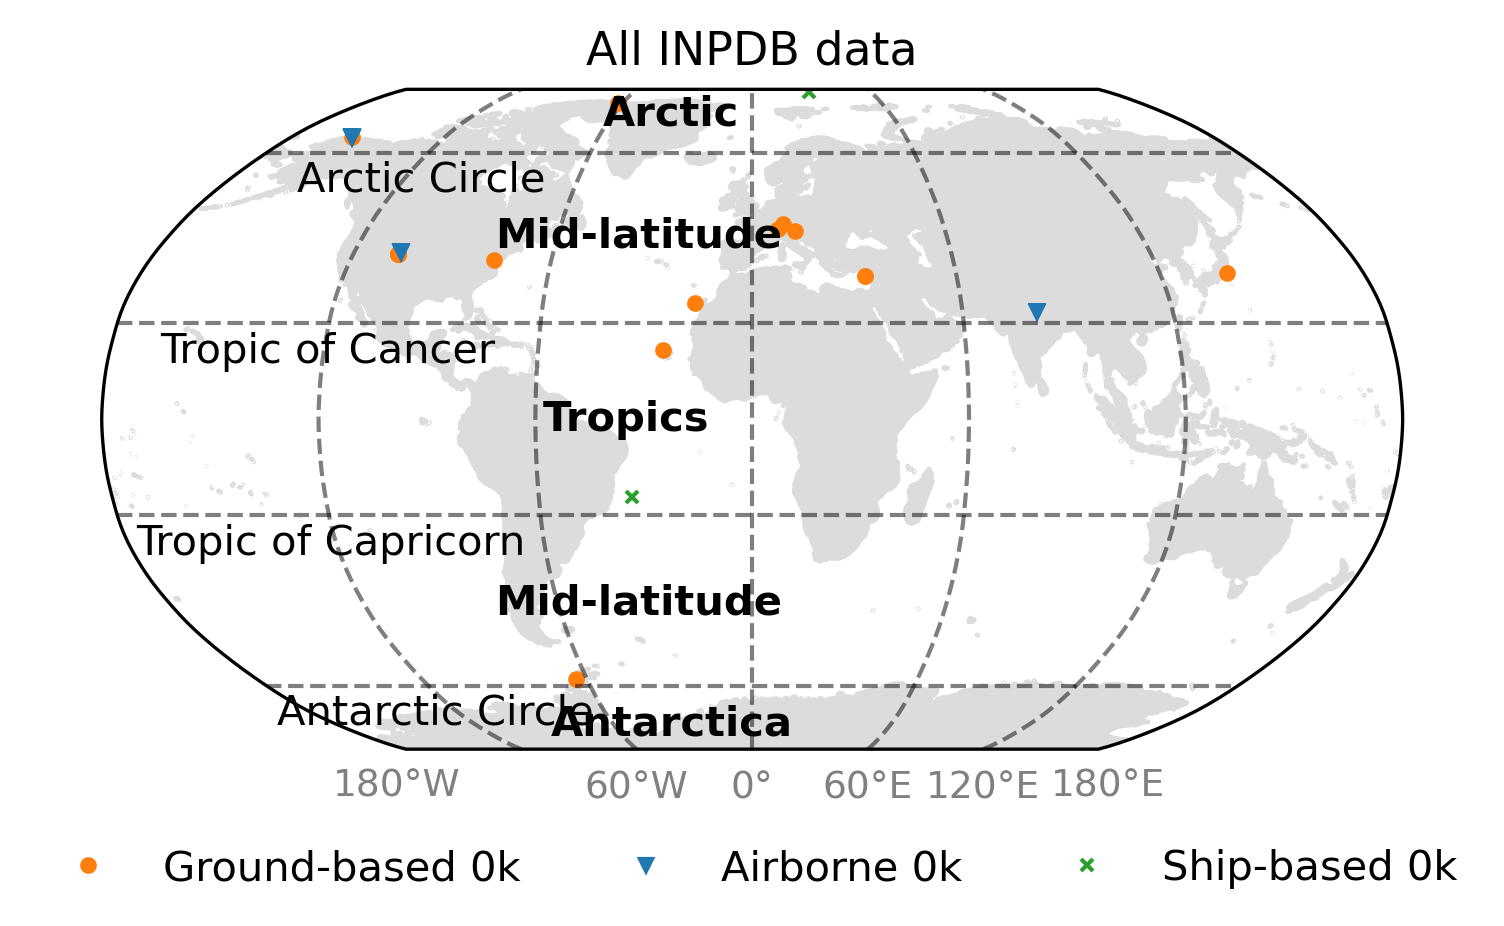

In [ ]:
def mapRobinson(data, title, saveFig=False):
    
    fig = plt.figure(figsize=(6, 3), dpi=300, constrained_layout=True) ## Define the figure and specify size
    ## ax = plt.subplot(1,1,1, projection=ccrs.PlateCarree()) ## Specify plot area & projection
    ax = plt.subplot(1,1,1, projection=ccrs.Robinson(central_longitude=0, globe=None)) ## Specify plot area & projection
    ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor="gainsboro"))
    ax.set_global()
    ax.set_title(title, fontsize=11) ## Set figure title
    ## you must declare the coordinate system of (lons, lats) with the statement "transform=??" correctly. 
    ## If (lons, lats) are in simple decimal degrees, you always use transform=ccrs.PlateCarree() no matter what the plotting projection is
    ## https://stackoverflow.com/questions/78449917/how-to-plot-cartopy-pcolormesh-with-robinson-projection
    data_Ground=data[data['Platform'] == 'Ground']
    data_Air=data[data['Platform'] == 'Air']
    data_Ship=data[data['Platform'] == 'Ship']
    platform_region_stats = data.groupby(['Platform']).size()
    ax.plot(data_Ground.Lon, data_Ground.Lat, marker='o', ls = ' ', ms=3, color="C1", label = f"Ground-based {platform_region_stats['Ground']/1000:.0f}k", transform=ccrs.PlateCarree())
    ax.plot(data_Air.Lon, data_Air.Lat, marker='v', ls = ' ', ms=3, color="C0", label = f"Airborne {platform_region_stats['Air']/1000:.0f}k", transform=ccrs.PlateCarree())
    ax.plot(data_Ship.Lon, data_Ship.Lat, marker='x', ls = ' ', ms=3, color="C2", label = f"Ship-based {platform_region_stats['Ship']/1000:.0f}k", transform=ccrs.PlateCarree())

    gl=ax.gridlines(draw_labels="x", linewidth=1, color='k', alpha=0.5, linestyle='--', transform=ccrs.PlateCarree()) ## Add lat/lon grid
    circles = [-66.56083, -23.43607, 23.43607, 66.56083]
    circleLabels = ["Antarctic Circle", "Tropic of Capricorn", "Tropic of Cancer", "Arctic Circle"]
    Regions = ['Antarctica', "Mid-latitude", "Tropics", "Mid-latitude", "Arctic"]
    gl.ylocator = mticker.FixedLocator(circles)
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 9, 'color': 'gray'}
    gl.ylabel_style = {'size': 9, 'color': 'gray'}
    gl.top_labels = False
    gl.xlines = True
    for lat, s in zip(circles, circleLabels):
        ax.text(y=lat-2, x=-120, s=s, va='top', ha='center', transform=ccrs.PlateCarree())
    for lat, s in zip([-78.3, -45, 0, 45, 78.3], Regions):
        ax.text(y=lat, x=-35, s=s, va='center', ha='center', fontweight='bold', transform=ccrs.PlateCarree())
    ## ax.legend(bbox_to_anchor=(0., 0.), loc="lower center", ncol=1, frameon=True, prop={'size': 9})
    fig.legend(loc="outside lower center", ncol=3, frameon=False, prop={'size': 10})
    if saveFig:
        fn = os.path.join("Output", title + ".png")
        if not os.path.exists(fn):
                plt.savefig(fn, dpi=600, bbox_inches='tight', pad_inches=0)
    return fig, ax

mapRobinson(data, "All INPDB data", saveFig=True)